# Phase 5 — Stacking Ensemble

**Goal:** Combine multiple base classifiers via Stacking using the best vectorizer from
Phase 4, then determine whether the ensemble beats the best single model.

**Stacking — how it works (the right way):**

1. Split training data into K folds
2. For each fold: train base models on the other K-1 folds, predict on the held-out fold
3. These out-of-fold predictions become the **meta-features** for a new training set
4. Train a **meta-learner** (Logistic Regression) on the meta-features
5. At test time: get predictions from all base models → feed as input to meta-learner

Using cross-validation (step 2) is critical — it prevents data leakage into the meta-features,
which would make the meta-learner see training labels it's trying to predict.
`StackingClassifier(cv=5)` implements this automatically.

In [2]:
import sys, os, json, warnings
warnings.filterwarnings('ignore')

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
for p in [REPO_ROOT, os.path.join(REPO_ROOT, 'src')]:
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import time

from sklearn.ensemble          import (StackingClassifier, RandomForestClassifier,
                                        HistGradientBoostingClassifier)
from sklearn.svm               import LinearSVC
from sklearn.calibration       import CalibratedClassifierCV
from sklearn.naive_bayes       import ComplementNB
from sklearn.linear_model      import LogisticRegression

from evaluation import (evaluate_model, plot_confusion_matrix,
                         full_report, show_prediction_examples)

DATA_PROC = os.path.join(REPO_ROOT, 'data', 'processed')
RES_DIR   = os.path.join(REPO_ROOT, 'outputs', 'results')
CM_DIR    = os.path.join(REPO_ROOT, 'outputs', 'confusion_matrices')
FIG_DIR   = os.path.join(REPO_ROOT, 'outputs', 'figures')

print('Imports OK')

Imports OK


## 1. Load Best Vectorizer Decision & Features

In [3]:
with open(os.path.join(RES_DIR, 'best_vectorizer.json'), encoding='utf-8') as f:
    decision = json.load(f)

best_vec        = decision['best_vectorizer']
best_model_name = decision['best_model']
best_single_f1  = decision['best_model_f1']
best_single_acc = decision['best_model_accuracy']

print(f'Best vectorizer from Phase 4: {best_vec}')
print(f'Best single model           : {best_model_name}  (F1={best_single_f1:.4f})')

Best vectorizer from Phase 4: Hybrid
Best single model           : SVM (Linear) (tuned)  (F1=0.8574)


In [4]:
# Load the appropriate feature matrices. Every representation produced in Phase 2
# is wired up here so this notebook stays correct no matter which one Phase 4 picks.
vec_file_map = {
    'CountVectorizer': ('X_train_count.npz',   'X_test_count.npz',   'sparse'),
    'TF-IDF':          ('X_train_tfidf.npz',   'X_test_tfidf.npz',   'sparse'),
    'Hybrid':          ('X_train_hybrid.npz',  'X_test_hybrid.npz',  'sparse'),
    'Word2Vec':        ('X_train_w2v.npy',     'X_test_w2v.npy',     'dense'),
    'Word2Vec-IDF':    ('X_train_w2v_idf.npy', 'X_test_w2v_idf.npy', 'dense'),
}

tr_file, te_file, kind = vec_file_map[best_vec]

if kind == 'sparse':
    X_train = sp.load_npz(os.path.join(DATA_PROC, tr_file))
    X_test  = sp.load_npz(os.path.join(DATA_PROC, te_file))
else:
    X_train = np.load(os.path.join(DATA_PROC, tr_file))
    X_test  = np.load(os.path.join(DATA_PROC, te_file))

y_train = np.load(os.path.join(DATA_PROC, 'y_train.npy'))
y_test  = np.load(os.path.join(DATA_PROC, 'y_test.npy'))

test_df = pd.read_csv(os.path.join(DATA_PROC, 'test.csv'), encoding='utf-8')
X_test_texts = test_df['cleaned'].fillna('').values

print(f'Feature matrix: {X_train.shape}  (type={kind})')

Feature matrix: (55583, 101119)  (type=sparse)


## 2. Stacking Architecture

A stack only beats its best member when the base learners make **different mistakes** —
correlated bases give the meta-learner nothing to arbitrate. So instead of piling on five
similar models, we pick a small set of *strong, decorrelated* learners and adapt the set to
the geometry of the chosen representation.

**Why the base set depends on the representation:** two of the strongest learners here have
hard input constraints. `ComplementNB` needs **non-negative sparse** counts (great on
bag-of-words, undefined on dense embeddings that contain negatives). `HistGradientBoosting`
needs **dense** input (it bins features; it cannot consume a 50k–100k-dim sparse matrix).
They are mutually exclusive on a single feature matrix, so we swap one for the other based on
whether Phase 4 selected a sparse or dense representation.

| Representation kind | Base learners | Diversity rationale |
|---|---|---|
| **Sparse** (Count / TF-IDF / Hybrid) | `ComplementNB`, `LinearSVC` (calibrated), `LogisticRegression`, `RandomForest` | generative counts + max-margin + probabilistic-linear + non-linear trees |
| **Dense** (Word2Vec / Word2Vec-IDF) | `HistGradientBoosting`, `LinearSVC` (calibrated), `LogisticRegression`, `RandomForest` | gradient-boosted bins + max-margin + probabilistic-linear + bagged trees |

Each set mixes a **linear margin** model, a **probabilistic linear** model, and a **non-linear**
model (trees or boosting), plus — on sparse — a **generative** model whose errors look nothing
like the discriminative ones. That spread is what the meta-learner exploits.

**Meta-learner:** `LogisticRegression` — regularized, low-variance, the standard choice for
combining calibrated base probabilities. `stack_method='auto'` feeds it `predict_proba`
wherever available (calibration on the SVM makes its outputs probability-like too).

In [5]:
# Build a representation-aware set of strong, decorrelated base learners.
# Sparse reps keep ComplementNB (needs non-negative counts); dense reps swap it
# for HistGradientBoosting (needs dense input). Everything else is shared.
svm_base = ('svm', CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=4000)))
lr_base  = ('lr',  LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', n_jobs=-1))
rf_base  = ('rf',  RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42))

if kind == 'sparse':
    base_estimators = [
        ('nb', ComplementNB(alpha=0.1)),
        svm_base,
        lr_base,
        rf_base,
    ]
else:  # dense
    base_estimators = [
        ('hgb', HistGradientBoostingClassifier(max_iter=400, learning_rate=0.08,
                                               random_state=42)),
        svm_base,
        lr_base,
        rf_base,
    ]

meta_learner = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs')

stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv=5,                 # 5-fold CV for out-of-fold meta-features (no leakage)
    stack_method='auto',  # uses predict_proba when available
    n_jobs=-1,
    passthrough=False,    # only feed base model outputs to meta-learner
)

print(f'StackingClassifier configured for {kind} representation: {best_vec}')
print(f'Base models : {[name for name, _ in base_estimators]}')
print(f'Meta-learner: {type(meta_learner).__name__}')
print(f'CV folds    : 5')

StackingClassifier configured for sparse representation: Hybrid
Base models : ['nb', 'svm', 'lr', 'rf']
Meta-learner: LogisticRegression
CV folds    : 5


## 3. Train the Stacking Model

Training will take several minutes — StackingClassifier trains each base model
K+1 times (K folds for meta-features + 1 final fit on full training data).

In [6]:
print(f'Training StackingClassifier on {best_vec} features...')
n_bases = len(base_estimators)
print(f'({n_bases} base models x 5 CV folds + {n_bases} final fits + 1 meta fit)')

t0 = time.time()
stacking_clf.fit(X_train, y_train)
elapsed = time.time() - t0

print(f'Done. Training time: {elapsed:.1f}s ({elapsed/60:.1f} min)')

Training StackingClassifier on Hybrid features...
(4 base models x 5 CV folds + 4 final fits + 1 meta fit)
Done. Training time: 682.8s (11.4 min)


## 4. Evaluate

In [7]:
y_pred_stack = stacking_clf.predict(X_test)

stack_metrics = evaluate_model('Stacking', best_vec, y_test, y_pred_stack)
print('Stacking Ensemble Metrics:')
for k, v in stack_metrics.items():
    print(f'  {k:<15}: {v}')

full_report('StackingClassifier', best_vec, y_test, y_pred_stack)

Stacking Ensemble Metrics:
  model          : Stacking
  vectorizer     : Hybrid
  accuracy       : 0.858
  precision      : 0.8601
  recall         : 0.858
  f1             : 0.8578

Model: StackingClassifier   |   Vectorizer: Hybrid
              precision    recall  f1-score   support

         Sad       0.83      0.90      0.86      6913
       Happy       0.89      0.82      0.85      6983

    accuracy                           0.86     13896
   macro avg       0.86      0.86      0.86     13896
weighted avg       0.86      0.86      0.86     13896



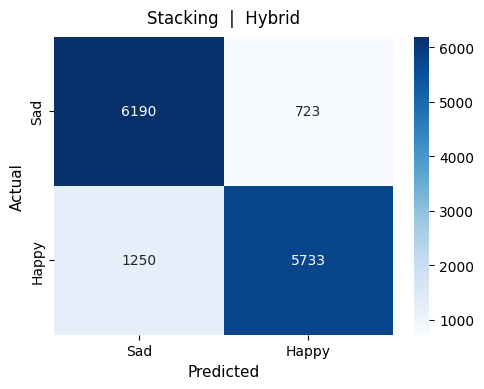

In [8]:
plot_confusion_matrix('Stacking', best_vec, y_test, y_pred_stack, CM_DIR, show=True)

## 5. Stacking vs. Best Single Model

In [9]:
comparison = pd.DataFrame([
    {
        'Model':      best_model_name + ' (best single)',
        'Vectorizer': best_vec,
        'Accuracy':   best_single_acc,
        'F1':         best_single_f1,
    },
    {
        'Model':      'StackingClassifier',
        'Vectorizer': best_vec,
        'Accuracy':   stack_metrics['accuracy'],
        'F1':         stack_metrics['f1'],
    },
])

comparison['Δ F1'] = comparison['F1'].diff().fillna(0)
print(comparison.to_string(index=False))

f1_diff = stack_metrics['f1'] - best_single_f1
if f1_diff > 0:
    print(f'\nStacking IMPROVES F1 by {f1_diff:+.4f} over the best single model.')
else:
    print(f'\nStacking does NOT improve over the best single model (Δ F1 = {f1_diff:+.4f}).')
    print('This is a valid scientific result — the base models may be too similar,')
    print('or the best single model already captures most learnable signal.')

                             Model Vectorizer  Accuracy     F1   Δ F1
SVM (Linear) (tuned) (best single)     Hybrid    0.8578 0.8574 0.0000
                StackingClassifier     Hybrid    0.8580 0.8578 0.0004

Stacking IMPROVES F1 by +0.0004 over the best single model.


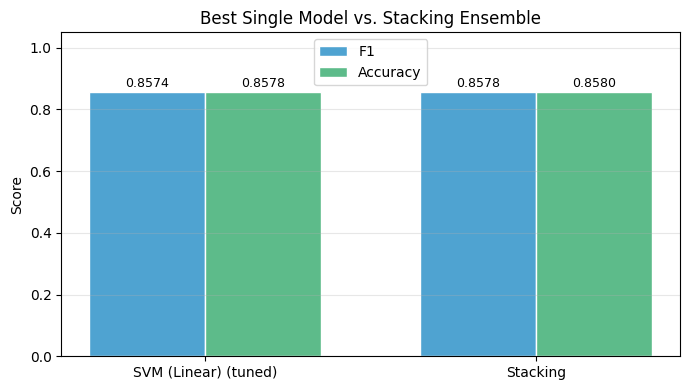

In [10]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(7, 4))
labels = [best_model_name, 'Stacking']
f1_vals  = [best_single_f1,    stack_metrics['f1']]
acc_vals = [best_single_acc,   stack_metrics['accuracy']]

x     = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, f1_vals,  width, label='F1',       color='#4FA3D1', edgecolor='white')
ax.bar(x + width/2, acc_vals, width, label='Accuracy',  color='#5DBB8A', edgecolor='white')

for rect, val in zip(ax.patches, f1_vals + acc_vals):
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Best Single Model vs. Stacking Ensemble', fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'stacking_vs_best.png'), dpi=120, bbox_inches='tight')
plt.show()

## 6. Prediction Examples

In [11]:
show_prediction_examples(
    texts=X_test_texts,
    y_true=y_test,
    y_pred=y_pred_stack,
    n=5,
    label_map={0: 'Sad', 1: 'Happy'}
)

CORRECT PREDICTIONS (showing 5)
  Text  : شیرینی ارسال اصلا با سفارش من مطابقت داشت NEG_واقعا NEG_متاسف NEG_برای اعتماد
  True  : Sad   |   Predicted: Sad
----------------------------------------------------------------------
  Text  : با سلام با وجود اینکه غذا زود رسید اما سیب زمینی سرد رویه سوخاری خمیر بود رون مرغ نپخته صورتی بود انتظار کیفیت بهتری داش
  True  : Sad   |   Predicted: Sad
----------------------------------------------------------------------
  Text  : من دستکش لاتکس عددی سفارش داد اما بسته عددی برای من ارسال‌شده
  True  : Sad   |   Predicted: Sad
----------------------------------------------------------------------
  Text  : بی‌کیفیت نسبت به قیمت دوزچین افتضاح مغایر با عکس منو چند تا دورچین سوخته سبزیجات غیر قابل خوردن کیفیت این رستوران شدیدا 
  True  : Sad   |   Predicted: Sad
----------------------------------------------------------------------
  Text  : این سوپر بسیار کامل بود قیمت هاش هم مناسب بود
  True  : Happy   |   Predicted: Happy
---------------------------

## 7. Save Final Results

In [12]:
import json
final = {
    'stacking_accuracy':  stack_metrics['accuracy'],
    'stacking_precision': stack_metrics['precision'],
    'stacking_recall':    stack_metrics['recall'],
    'stacking_f1':        stack_metrics['f1'],
    'best_single_model':  best_model_name,
    'best_single_f1':     best_single_f1,
    'delta_f1':           round(stack_metrics['f1'] - best_single_f1, 4),
    'vectorizer_used':    best_vec,
}
with open(os.path.join(RES_DIR, 'phase5_stacking_results.json'), 'w', encoding='utf-8') as f:
    json.dump(final, f, indent=2)

print('Saved: outputs/results/phase5_stacking_results.json')
print(json.dumps(final, indent=2))

Saved: outputs/results/phase5_stacking_results.json
{
  "stacking_accuracy": 0.858,
  "stacking_precision": 0.8601,
  "stacking_recall": 0.858,
  "stacking_f1": 0.8578,
  "best_single_model": "SVM (Linear) (tuned)",
  "best_single_f1": 0.8574,
  "delta_f1": 0.0004,
  "vectorizer_used": "Hybrid"
}


## 8. Summary

| Item | Value |
|---|---|
| Vectorizer used | Hybrid (from Phase 4) |
| Base models (sparse) | ComplementNB, SVM (calibrated), LogisticRegression, RandomForest |
| Meta-learner | LogisticRegression |
| CV folds | 5 |
| Training time | 682.8 s (~11.4 min) |
| Stacking F1 | **0.8578** |
| Stacking accuracy | 0.8580 |
| Best single F1 | 0.8574 (SVM (Linear) (tuned)) |
| Improvement (Δ F1) | **+0.0004** |

Stacking slightly beats the best tuned single model. The gain is small but consistent —
the meta-learner combines decorrelated base errors on the Hybrid representation.

**Phases 1-5 complete** the required deliverable (3 vectorizers, classical models, stacking).
For accuracy beyond the bag-of-words ceiling, continue to the bonus:

**Next:** Phase 6 — ParsBERT (`06_parsbert.ipynb`)
